In [1]:
import pandas as pd
import numpy as np
import re

import matplotlib.pyplot as plt
import seaborn as sns

import pywmapi as wm
import requests



import warnings
warnings.simplefilter(action='ignore', category=FutureWarning)

# WF market prices

In [2]:
elements = [
    "Hydroid Prime", "Khora Prime", "Inaros Prime", "Zephyr Prime",
    "Nidus Prime", "Mirage Prime", "Titania Prime", "Harrow Prime",
    "Rhino Prime", "Chroma Prime", "Mesa Prime", "Nyx Prime"
]

def wf_df(elements):
    # Création du DataFrame
    df = pd.DataFrame(elements, columns=["chat_name"])
     
    # Transformation des éléments
    df['market_name'] = df['chat_name'].str.lower().str.replace(' ', '_') + '_set'
    
    return df

In [3]:
df = wf_df(elements)
df

,chat_name,market_name
0,Hydroid Prime,hydroid_prime_set
1,Khora Prime,khora_prime_set
2,Inaros Prime,inaros_prime_set
3,Zephyr Prime,zephyr_prime_set
4,Nidus Prime,nidus_prime_set
5,Mirage Prime,mirage_prime_set
6,Titania Prime,titania_prime_set
7,Harrow Prime,harrow_prime_set
8,Rhino Prime,rhino_prime_set
9,Chroma Prime,chroma_prime_set


In [4]:
def print_msg(elements):
    # Imprimer le message de vente selon contenu liste elements
    print("WTS ", end='')
    for element in elements:
        print(f"[{element}]", end='')
    
    print(" sets PMO")

In [5]:
item_name = "chroma_prime_systems"

In [7]:
data_orders = wm.orders.get_orders(item_name)
# Create a DataFrame
df_orders = pd.DataFrame([{
    "item_name":item_name,
    "id": item.id,
    "platinum": item.platinum,
    "quantity": item.quantity,
    "order_type": item.order_type,
    "visible": item.visible,
    "region": item.region,
    "creation_date": item.creation_date,
    "closed_date": item.closed_date,
    "last_update": item.last_update,
    "user_id": item.user.id,
    "user_status": item.user.status,
    "user_region": item.user.region,
    "user_reputation": item.user.reputation,
    "user_last_seen": item.user.last_seen,
    "user_ingame_name": item.user.ingame_name,
    "user_avatar": item.user.avatar
} for item in data_orders])

df_orders['user_status'] = df_orders['user_status'].astype(str)
df_orders['order_type'] = df_orders['order_type'].astype(str)

df_orders['user_status'] = df_orders['user_status'].str.replace('Status.', '')
df_orders['order_type'] = df_orders['order_type'].str.replace('OrderType.', '')

In [8]:
df_orders.head()

,item_name,id,platinum,quantity,order_type,visible,region,creation_date,closed_date,last_update,user_id,user_status,user_region,user_reputation,user_last_seen,user_ingame_name,user_avatar
0,chroma_prime_systems,5db10c9135f88608870cd578,35,1,sell,True,en,2019-10-24 02:29:37+00:00,None,2025-03-18 05:56:52+00:00,5ccb40a44532a60806ad67b2,offline,en,2,2025-05-08 07:35:32.538000+00:00,Kiorri,None
1,chroma_prime_systems,61de9052a6b649125b246524,40,1,sell,True,en,2022-01-12 08:24:50+00:00,None,2022-08-07 22:20:52+00:00,5b6eb237492621022c259303,offline,en,115,2025-05-08 12:52:54.317000+00:00,-R1CKY-,user/avatar/5b6eb237492621022c259303.png?32842...
2,chroma_prime_systems,621ee075756712011d6ac56f,29,1,sell,True,en,2022-03-02 03:11:49+00:00,None,2025-04-18 15:51:41+00:00,5f5b3aab0d792401ad4fa6db,offline,en,153,2025-05-07 10:52:32.354000+00:00,LevelFive,None
3,chroma_prime_systems,62753e8f596f2f0680fa8017,20,1,sell,True,en,2022-05-06 15:28:15+00:00,None,2025-04-03 20:49:10+00:00,5ea7fde4aad7770104287f80,offline,en,4,2025-05-08 18:35:02.931000+00:00,Milan.K,None
4,chroma_prime_systems,62b0bd1f5658b308fe2a5142,28,30,sell,True,en,2022-06-20 18:31:59+00:00,None,2025-04-11 13:18:38+00:00,57b44c07d3ffb652fcde3199,offline,en,122,2025-05-03 07:15:38.729000+00:00,Alkatrosto,None


In [9]:
df_orders['user_status'].value_counts()

offline    382
ingame      16
online       4
Name: user_status, dtype: int64

In [10]:
df_orders['order_type'].value_counts()

sell    363
buy      39
Name: order_type, dtype: int64

In [11]:
def item_query_info(item_name, user_status='ingame', order_type='sell', show_user=False, ascending=True):
    data_orders = wm.orders.get_orders(item_name)
    # Create a DataFrame
    df_orders = pd.DataFrame([{
        "item_name":item_name,
        "id": item.id,
        "platinum": item.platinum,
        "quantity": item.quantity,
        "order_type": item.order_type,
        "visible": item.visible,
        "region": item.region,
        "creation_date": item.creation_date,
        "closed_date": item.closed_date,
        "last_update": item.last_update,
        "user_id": item.user.id,
        "user_status": item.user.status,
        "user_region": item.user.region,
        "user_reputation": item.user.reputation,
        "user_last_seen": item.user.last_seen,
        "user_ingame_name": item.user.ingame_name,
        "user_avatar": item.user.avatar
    } for item in data_orders])
    
    df_orders['user_status'] = df_orders['user_status'].astype(str)
    df_orders['order_type'] = df_orders['order_type'].astype(str)
    
    df_orders['user_status'] = df_orders['user_status'].str.replace('Status.', '')
    df_orders['order_type'] = df_orders['order_type'].str.replace('OrderType.', '')

    if show_user==True:
        orders_mask = ['user_id', 'item_name', 'platinum', 'quantity', 'order_type', 'user_status']
    else:
        orders_mask = ['item_name','platinum', 'quantity', 'order_type', 'user_status']
        
    df_orders_filtered = df_orders[(df_orders['user_status'] == user_status) & (df_orders['order_type'] == order_type)]
    df_orders_filtered = df_orders_filtered[orders_mask].sort_values(by='platinum', ascending=ascending).reset_index(drop=True)
    return df_orders_filtered

In [12]:
item_name = "chroma_prime_systems"
item_query_info(item_name, show_user=True)

,user_id,item_name,platinum,quantity,order_type,user_status
0,5e8d788a8deffd06dbd520d7,chroma_prime_systems,20,1,sell,ingame
1,5cb86d74aa72901053d006aa,chroma_prime_systems,25,1,sell,ingame
2,6801692f18d77f0008fd116c,chroma_prime_systems,25,1,sell,ingame
3,681125e6353ea100fdb81296,chroma_prime_systems,25,1,sell,ingame
4,5b562ca20d860103b05f9312,chroma_prime_systems,26,1,sell,ingame
5,6326f11abe305e00c21bd9a0,chroma_prime_systems,29,10,sell,ingame
6,65098f77b840f805b5aeb38f,chroma_prime_systems,30,6,sell,ingame
7,66d49834c405f62da23d9dee,chroma_prime_systems,30,1,sell,ingame
8,68155c73ff901601635d4db8,chroma_prime_systems,30,1,sell,ingame
9,5a1efc9aa15fed001323a113,chroma_prime_systems,30,1,sell,ingame


In [13]:
chroma = item_query_info(item_name)

In [14]:
chroma['platinum'].median()

30.0

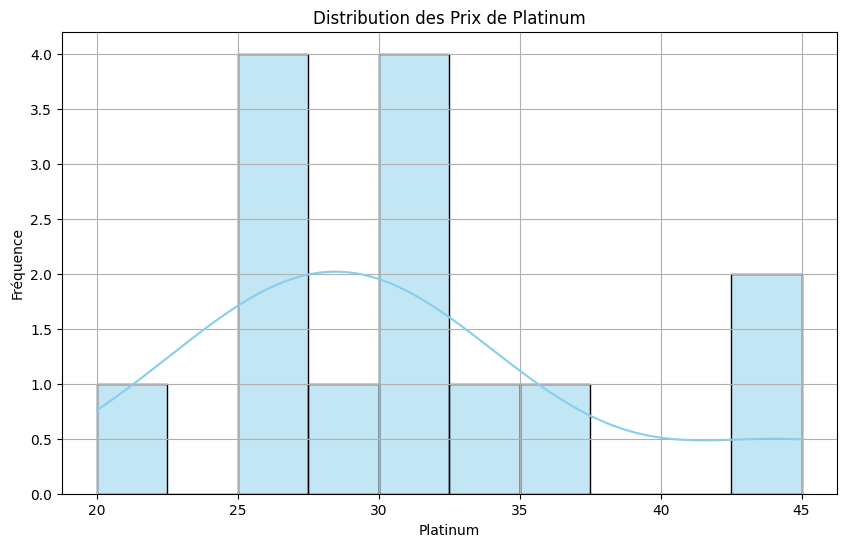

In [15]:

plt.figure(figsize=(10, 6))
sns.histplot(chroma['platinum'], bins=10, kde=True, color='skyblue')
plt.title('Distribution des Prix de Platinum')
plt.xlabel('Platinum')
plt.ylabel('Fréquence')
plt.grid(True)
plt.show()

In [30]:
item_name = df['market_name'][1]
item_name

'khora_prime_set'

In [31]:
item_query_info(item_name)

,item_name,platinum,quantity,order_type,user_status
0,khora_prime_set,75,2,sell,ingame
1,khora_prime_set,78,2,sell,ingame
2,khora_prime_set,79,1,sell,ingame
3,khora_prime_set,79,5,sell,ingame
4,khora_prime_set,80,1,sell,ingame
5,khora_prime_set,80,2,sell,ingame
6,khora_prime_set,80,5,sell,ingame
7,khora_prime_set,80,20,sell,ingame
8,khora_prime_set,80,4,sell,ingame
9,khora_prime_set,80,1,sell,ingame


In [33]:
for item in df['market_name']:
    query = item_query_info(item)
    median = query['platinum'].median()
    print(f'{item} median : {median}')
    print(query)

hydroid_prime_set median : 100.0
            item_name  platinum  quantity order_type user_status
0   hydroid_prime_set        89         1       sell      ingame
1   hydroid_prime_set        89         1       sell      ingame
2   hydroid_prime_set        90         1       sell      ingame
3   hydroid_prime_set        92         1       sell      ingame
4   hydroid_prime_set        94         3       sell      ingame
5   hydroid_prime_set        95         1       sell      ingame
6   hydroid_prime_set        95         6       sell      ingame
7   hydroid_prime_set        95         1       sell      ingame
8   hydroid_prime_set        99         1       sell      ingame
9   hydroid_prime_set        99         1       sell      ingame
10  hydroid_prime_set        99         4       sell      ingame
11  hydroid_prime_set        99         5       sell      ingame
12  hydroid_prime_set       100         8       sell      ingame
13  hydroid_prime_set       100        20       sell     

In [34]:
df

,chat_name,market_name
0,Hydroid Prime,hydroid_prime_set
1,Khora Prime,khora_prime_set
2,Inaros Prime,inaros_prime_set
3,Zephyr Prime,zephyr_prime_set
4,Nidus Prime,nidus_prime_set
5,Mirage Prime,mirage_prime_set
6,Titania Prime,titania_prime_set
7,Harrow Prime,harrow_prime_set
8,Rhino Prime,rhino_prime_set
9,Chroma Prime,chroma_prime_set


In [35]:
def item_query_info_median(row):
    df = item_query_info(row)
    median = int(df['platinum'].median())
    return median

In [36]:
item_query_info_median('nyx_prime_set')

115

# items

In [37]:
json_items = wm.items.list_items()

In [38]:
# Utilisation d'une expression régulière pour extraire les données
pattern = r"ItemShort\(id='([^']+)', url_name='([^']+)', thumb='([^']+)', item_name='([^']+)'\)"

# Trouver toutes les correspondances dans le texte
matches = re.findall(pattern, str(json_items))

# Création du DataFrame
df_item_info = pd.DataFrame(matches, columns=['id', 'url_name', 'thumb', 'item_name'])

In [39]:
df_item_info

,id,url_name,thumb,item_name
0,54aae292e7798909064f1575,secura_dual_cestra,items/images/en/thumbs/secura_dual_cestra.3d47...,Secura Dual Cestra
1,54ca39abe7798915c1c11e10,creeping_bullseye,items/images/en/thumbs/creeping_bullseye.dfcb8...,Creeping Bullseye
2,54d4c727e77989281cc7d753,mutalist_alad_v_assassinate_key,items/images/en/thumbs/mutalist_alad_v_assassi...,Mutalist Alad V Assassinate (Key)
3,54e0c9eee7798903744178b0,irradiating_disarm,items/images/en/thumbs/irradiating_disarm.cffd...,Irradiating Disarm
4,54e644ffe779897594fa68cf,antimatter_absorb,items/images/en/thumbs/antimatter_absorb.1402d...,Antimatter Absorb
...,...,...,...,...
3506,67e8c996cedcd0be6d13595a,dual_viciss_blade,sub_icons/weapon/generic_blade_128x128.png,Dual Viciss Blade
3507,67e8c997cedcd0be6d13595b,dual_viciss_hilt,sub_icons/weapon/generic_hilt_128x128.png,Dual Viciss Hilt
3508,67eff367cedcd0be6d13595e,primed_steady_hands,items/unknown.thumb.png,Primed Steady Hands
3509,68028a0a24bd8dc3de5797d4,primed_stabilizer,items/unknown.thumb.png,Primed Stabilizer


# Consolidation

## Price Point

In [40]:
elements = [
    "Hydroid Prime", "Khora Prime", "Inaros Prime", "Zephyr Prime",
    "Nidus Prime", "Mirage Prime", "Titania Prime", "Harrow Prime",
    "Rhino Prime", "Chroma Prime", "Mesa Prime", "Nyx Prime"
]

In [41]:
df = wf_df(elements)

In [42]:
df['market_price_median'] = df['market_name'].apply(item_query_info_median)

In [43]:
df['chat_price'] = df['market_price_median'] + 40
df['chat_price_abus'] = df['market_price_median'] * 2

df

,chat_name,market_name,market_price_median,chat_price,chat_price_abus
0,Hydroid Prime,hydroid_prime_set,100,140,200
1,Khora Prime,khora_prime_set,84,124,168
2,Inaros Prime,inaros_prime_set,70,110,140
3,Zephyr Prime,zephyr_prime_set,95,135,190
4,Nidus Prime,nidus_prime_set,72,112,144
5,Mirage Prime,mirage_prime_set,90,130,180
6,Titania Prime,titania_prime_set,80,120,160
7,Harrow Prime,harrow_prime_set,66,106,132
8,Rhino Prime,rhino_prime_set,80,120,160
9,Chroma Prime,chroma_prime_set,90,130,180


## Market msg

In [44]:
print_msg(elements)

WTS [Hydroid Prime][Khora Prime][Inaros Prime][Zephyr Prime][Nidus Prime][Mirage Prime][Titania Prime][Harrow Prime][Rhino Prime][Chroma Prime][Mesa Prime][Nyx Prime] sets PMO


In [253]:
len_msg = 140 - len("WTS ")
len_msg

136

In [260]:
# Créer le message complet
message_parts = [f"[{row['chat_name']}]{row['chat_price']}" for _, row in df.iterrows()]
full_message = ", ".join(message_parts)

# Diviser en plusieurs messages "WTS" si nécessaire
messages = []
current_message = "WTS "
max_len = 140
avalaible_len = max_len - len(current_message)

for part in message_parts:
    if len(current_message) + len(part) + 2 <= avalaible_len:  # +2 pour ", "
        current_message += f"{part}, "
    else:
        messages.append(current_message.rstrip(", "))
        current_message = f"WTS {part}, "

if current_message != "WTS ":
    messages.append(current_message.rstrip(", "))

# Afficher
for message in messages:
    print(len(message))
    print(message)

115
WTS [Hydroid Prime]140, [Khora Prime]120, [Inaros Prime]110, [Zephyr Prime]140, [Nidus Prime]115, [Mirage Prime]125
111
WTS [Titania Prime]120, [Harrow Prime]108, [Rhino Prime]120, [Chroma Prime]128, [Mesa Prime]129, [Nyx Prime]150


# Rivens 

In [3]:
riven_data = wm.rivens.list_items()

In [7]:
# Regular expression pattern to extract the data
pattern = r"RivenItem\(id='([^']+)', url_name='([^']+)', group=<Group\.([^:]+): '[^']+'>, riven_type=<WeaponType\.([^:]+): '[^']+'>, icon='([^']+)', thumb='([^']+)', item_name='([^']+)', icon_format=<IconFormat\.([^:]+): '[^']+'>\)"

# Find all matches in the text
matches = re.findall(pattern, str(riven_data))

# Convert matches to a list of dictionaries
riven_items_list = [
    {
        "id": match[0],
        "url_name": match[1],
        "group": match[2],
        "riven_type": match[3],
        "icon": match[4],
        "thumb": match[5],
        "item_name": match[6],
        "icon_format": match[7]
    }
    for match in matches
]

# Convert the list of dictionaries to a DataFrame
df_riven_itm = pd.DataFrame(riven_items_list).rename(columns={'url_name': 'item_name'})

In [31]:
df_riven_itm.head()

,id,item_name,group,riven_type,icon,thumb,item_name,icon_format
0,5c5ca81696e8d2003834fdcc,kulstar,secondary,pistol,items/images/en/kulstar.92736ca911a3b84f99bc9e...,items/images/en/thumbs/kulstar.92736ca911a3b84...,Kulstar,land
1,5c5ca81696e8d2003834fe1d,heliocor,melee,melee,items/images/en/heliocor.49fc1b3f6c4e4a550a15a...,items/images/en/thumbs/heliocor.49fc1b3f6c4e4a...,Heliocor,land
2,5cf5724d9597e1019b1678c5,nagantaka,primary,rifle,items/images/en/nagantaka.4ee86a7c5a800796a22e...,items/images/en/thumbs/nagantaka.4ee86a7c5a800...,Nagantaka,land
3,5cf5724e9597e1019b1678c6,ocucor,secondary,pistol,items/images/en/ocucor.c3f776ad9924de2782e8c0d...,items/images/en/thumbs/ocucor.c3f776ad9924de27...,Ocucor,land
4,5cf5724f9597e1019b1678c7,falcor,melee,melee,items/images/en/falcor.83897b2d4fbcbd312c70be4...,items/images/en/thumbs/falcor.83897b2d4fbcbd31...,Falcor,port


In [15]:
riven_attr = wm.rivens.list_attrs()

In [16]:
# Regular expression pattern to extract the data
pattern = r"RivenAttribute\(id='([^']+)', url_name='([^']+)', group=<Group\.([^:]+): '[^']+'>, positive_is_negative=([^,]+), effect='([^']+)', negative_only=([^,]+), search_only=([^,]+), prefix='([^']+)', suffix='([^']+)', exclusive_to=\[?([^\]]*)\]?, units=(?:<Units\.([^:]+): '[^']+'>|None)\)"

# Find all matches in the text
matches = re.findall(pattern, str(riven_attr))

# Convert matches to a list of dictionaries
riven_attributes_list = [
    {
        "id": match[0],
        "url_name": match[1],
        "group": match[2],
        "positive_is_negative": match[3] == 'True',
        "effect": match[4],
        "negative_only": match[5] == 'True',
        "search_only": match[6] == 'True',
        "prefix": match[7],
        "suffix": match[8],
        "exclusive_to": [wt.split(':')[1].strip().strip(">'") for wt in match[9].split(',') if ':' in wt] if match[9] and match[9] != 'None' else None,
        "units": match[10] if match[10] else None
    }
    for match in matches
]

# Convert the list of dictionaries to a DataFrame
df_riven_attr = pd.DataFrame(riven_attributes_list)

In [30]:
df_riven_attr.head()

,id,url_name,group,positive_is_negative,effect,negative_only,search_only,prefix,suffix,exclusive_to,units
0,5c5ca81a96e8d2003834fe63,ammo_maximum,default,False,Ammo Maximum,False,False,Ampi,Bin,"[shotgun, rifle, pistol, kitgun]",percent
1,5c5ca81a96e8d2003834fe64,damage_vs_corpus,default,False,Damage to Corpus,False,False,Manti,Tron,"[multiply'>), default, multiply'>), default, m...",None
2,5c5ca81a96e8d2003834fe69,channeling_efficiency,melee,False,Heavy Attack Efficiency,False,False,Forti,Us,"[melee, zaw]",percent
3,5c5ca81a96e8d2003834fe6a,combo_duration,melee,False,Combo Duration,False,False,Tempi,Nem,"[melee, zaw]",seconds
4,5c5ca81a96e8d2003834fe6b,critical_chance,default,False,Critical Chance,False,False,Crita,Cron,"[percent'>), melee, melee, zaw]",percent


In [210]:
def fetch_riven_info(weapon_name, buyout_policy='direct', sort_price='price_asc', owner_status='online_ingame'):
    # URL de l'API
    url = f"https://api.warframe.market/v1/auctions/search?type=riven&buyout_policy={buyout_policy}&weapon_url_name={weapon_name}&sort_by={sort_price}"
    
    # Envoyer une requête GET à l'API
    response = requests.get(url, headers=headers)
    
    # Vérifier si la requête a réussi
    if response.status_code == 200:
        # Convertir la réponse en JSON
        data = response.json()
    
        # Convertir le JSON en DataFrame en utilisant json_normalize
        df_auctions = pd.json_normalize(data['payload']['auctions'])
    
        # Ajouter les informations de l'objet 'item' en tant que colonnes
        item_data = [auction['item'] for auction in data['payload']['auctions']]
        item_df = pd.json_normalize(item_data)
    
        # Ajouter les informations des attributs
        for i in range(4):  # Il y a un maximum de 4 attributs
            df_auctions[f'attribute_{i}_value'] = df_auctions.apply(lambda row: row[f'item.attributes'][i]['value'] if i < len(row[f'item.attributes']) else None, axis=1)
            df_auctions[f'attribute_{i}_positive'] = df_auctions.apply(lambda row: row[f'item.attributes'][i]['positive'] if i < len(row[f'item.attributes']) else None, axis=1)
            df_auctions[f'attribute_{i}_name'] = df_auctions.apply(lambda row: row[f'item.attributes'][i]['url_name'] if i < len(row[f'item.attributes']) else None, axis=1)
    
        # Fusionner les DataFrames
        df_auctions = pd.concat([df_auctions, item_df], axis=1)
        df_auctions = df_auctions.drop(columns=['attributes'])
        df_auctions.columns = df_auctions.columns.str.replace('.', '_')
        

        # Filtrer
        if owner_status == "online":
            df_filtered = df_auctions.query("owner_status == 'online'")
        elif owner_status == "ingame":
            df_filtered =  df_auctions.query("owner_status == 'ingame'")
        elif owner_status == "online_ingame":
            df_filtered =  df_auctions.query("owner_status in ['online', 'ingame']")
        else:
            df_filtered = df

        mask = [ 'name', 'weapon_url_name', 'mod_rank', 'is_direct_sell', 'polarity',
                'buyout_price', 'starting_price', 'top_bid', 'created',
               'item_re_rolls', 'item_name', 'item_weapon_url_name', 'item_mod_rank', 'item_attributes',
               'owner_reputation', 'owner_platform', 'owner_locale', 'owner_last_seen',
               'owner_ingame_name', 'owner_crossplay', 'owner_status', 'owner_id',
               'owner_region','attribute_0_value',
               'attribute_0_positive', 'attribute_0_name', 'attribute_1_value',
               'attribute_1_positive', 'attribute_1_name', 'attribute_2_value',
               'attribute_2_positive', 'attribute_2_name', 'attribute_3_value',
               'attribute_3_positive', 'attribute_3_name', 're_rolls', 'id']

    else:
        print(f"La requête a échoué avec le code d'état : {response.status_code}")

    return df_auctions[mask]

In [211]:
torid_info = fetch_riven_info('torid', owner_status='online_ingame')

In [212]:
torid_info['owner_status'].value_counts()

offline    448
ingame      47
online       5
Name: owner_status, dtype: int64

In [213]:
torid_info.columns

Index(['name', 'weapon_url_name', 'mod_rank', 'is_direct_sell', 'polarity',
       'buyout_price', 'starting_price', 'top_bid', 'created', 'item_re_rolls',
       'item_name', 'item_weapon_url_name', 'item_mod_rank', 'item_attributes',
       'owner_reputation', 'owner_platform', 'owner_locale', 'owner_last_seen',
       'owner_ingame_name', 'owner_crossplay', 'owner_status', 'owner_id',
       'owner_region', 'attribute_0_value', 'attribute_0_positive',
       'attribute_0_name', 'attribute_1_value', 'attribute_1_positive',
       'attribute_1_name', 'attribute_2_value', 'attribute_2_positive',
       'attribute_2_name', 'attribute_3_value', 'attribute_3_positive',
       'attribute_3_name', 're_rolls', 'id'],
      dtype='object')

In [214]:
torid_info

,name,weapon_url_name,mod_rank,is_direct_sell,polarity,buyout_price,starting_price,top_bid,created,item_re_rolls,...,attribute_1_positive,attribute_1_name,attribute_2_value,attribute_2_positive,attribute_2_name,attribute_3_value,attribute_3_positive,attribute_3_name,re_rolls,id
0,crita-acritin,torid,8,True,naramon,1,1,None,2025-05-08T04:08:13.000+00:00,32,...,True,critical_damage,59.8,True,magazine_capacity,-49.10,False,ammo_maximum,32,681c2e2d353ea1027da3705e
1,armacron,torid,0,True,vazarin,435,435,None,2025-04-18T22:56:43.000+00:00,0,...,True,magazine_capacity,0.9,False,damage_vs_grineer,NaN,None,None,0,6802d8abfb9ffe0009a1776d
2,acri-toxides,torid,8,True,naramon,450,450,None,2025-05-06T19:59:53.000+00:00,85,...,True,status_duration,123.7,True,critical_damage,NaN,None,None,85,681a6a39fb9ffe021dfa0fe9
3,critatox,torid,8,True,madurai,499,499,None,2025-03-28T17:36:30.000+00:00,94,...,True,critical_chance,-34.1,False,magazine_capacity,NaN,None,None,94,67e6de1e19c10b000711cae9
4,crita-acricon,torid,0,True,madurai,500,500,None,2025-05-07T14:23:12.000+00:00,0,...,True,critical_damage,1.5,True,damage_vs_grineer,0.54,False,damage_vs_infested,0,681b6cd0f5ba0a023a690468
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
495,sati-acridex,torid,8,True,naramon,800,800,None,2025-05-08T08:24:11.000+00:00,171,...,True,status_chance,111.3,True,multishot,-63.60,False,fire_rate_/_attack_speed,171,681c6a2bff90160271706372
496,croni-acricron,torid,8,True,madurai,800,800,None,2025-05-08T07:55:09.000+00:00,55,...,True,critical_damage,187.7,True,critical_chance,-51.40,False,reload_speed,55,681c635dff90160265376f64
497,crita-zetiata,torid,0,True,madurai,800,800,None,2025-05-08T05:43:03.000+00:00,108,...,True,critical_chance,22.6,True,base_damage_/_melee_damage,-4.90,False,magazine_capacity,108,681c4467f5ba0a024692c618
498,visi-cronican,torid,8,True,vazarin,800,800,None,2025-05-08T02:25:54.000+00:00,42,...,True,multishot,213.4,True,base_damage_/_melee_damage,-61.30,False,zoom,42,681c16320067ad026a43652a


In [ ]:
# todo : find_cheap_highrolls()